<a href="https://colab.research.google.com/github/artHub-j/seat-cuprapoints/blob/main/SMAC_ML_session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) **Make a COPY of this notebook**

So you can run/edit/modify it.
```
File -> Save a copy in ...
```

2) **Install required libs**

In Google Colab, the exclamation mark (!) is used to run shell commands (e.g.,
pip install) directly from the notebook, because by default, Colab cells run Python code, not shell commands.

In [ ]:
!pip install pandas scikit-learn matplotlib numpy &> /dev/null

3) **Import libs**

In [ ]:
import pandas as pd               # Data handling in tabular form (DataFrames)
import numpy as np                # Numerical computations (arrays, math)
import matplotlib.pyplot as plt   # Plotting/visualization. By importing 'matplotlib.pyplot', you can use functions like 'plot()' and 'show()' to quickly and easily generate various types of charts and graphs

from sklearn.model_selection import train_test_split        # Splitting data into train/test. The train_test_split function from scikit-learn splits your data into training and testing sets
from sklearn.linear_model import LinearRegression           # Simple linear regression
from sklearn.metrics import mean_absolute_error, r2_score   # Error/determination metrics
                                                            # mean_absolute_error shows average prediction error
                                                            # r2_score indicates how well the model explains data variance; closer to 1 is better (100%)


4) **Load CSV file & initial inspection**

In [ ]:
# Uploading sample data from local drive. Select: temperture.csv
# Once loaded, this step can be skiped in following executions because
# the CSV file is stored temporarily
from google.colab import files
uploaded = files.upload()

# ... and convert the CSV into a DataFrame. df is a pandas DataFrame storing
# data in rows and columns
df = pd.read_csv("temperature.csv")
print(df.head())

# Keep only the datetime and Los Angeles columns
df = df[['datetime', 'Los Angeles']]

# Rename columns for clarity
df.columns = ['date', 'tempK']

# Display the first few rows of the DataFrame
print("First few rows:")
print(df.head())


              datetime   Vancouver    Portland  San Francisco     Seattle  \
0  2012-10-01 12:00:00         NaN         NaN            NaN         NaN   
1  2012-10-01 13:00:00  284.630000  282.080000     289.480000  281.800000   
2  2012-10-01 14:00:00  284.629041  282.083252     289.474993  281.797217   
3  2012-10-01 15:00:00  284.626998  282.091866     289.460618  281.789833   
4  2012-10-01 16:00:00  284.624955  282.100481     289.446243  281.782449   

   Los Angeles   San Diego   Las Vegas     Phoenix  Albuquerque  ...  \
0          NaN         NaN         NaN         NaN          NaN  ...   
1   291.870000  291.530000  293.410000  296.600000   285.120000  ...   
2   291.868186  291.533501  293.403141  296.608509   285.154558  ...   
3   291.862844  291.543355  293.392177  296.631487   285.233952  ...   
4   291.857503  291.553209  293.381213  296.654466   285.313345  ...   

   Philadelphia    New York    Montreal      Boston   Beersheba  \
0           NaN         NaN         N

5) **Clean and transform data**

In [ ]:
# Drop rows missing temperature: Drop NaN
# inplace=True applies changes directly to df without creating a new object
df.dropna(subset=['tempK'], inplace=True)

# pd.to_datetime converts the 'date' column from strings to datetime objects, enabling time-based operations
df['date'] = pd.to_datetime(df['date'])

# Convert Kelvin to Celsius
df['tempC'] = df['tempK'] - 273.15

print("\nAfter dropping missing and converting to Celsius:")
print(df.head())



After dropping missing and converting to Celsius:
                 date       tempK      tempC
1 2012-10-01 13:00:00  291.870000  18.720000
2 2012-10-01 14:00:00  291.868186  18.718186
3 2012-10-01 15:00:00  291.862844  18.712844
4 2012-10-01 16:00:00  291.857503  18.707503
5 2012-10-01 17:00:00  291.852162  18.702162


6) **Data visualization**

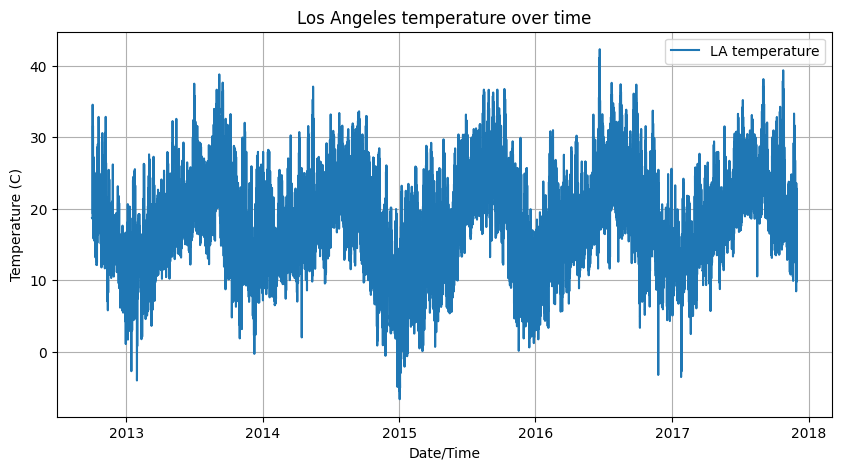

In [ ]:
# Sets the chart’s figure size to 10 inches by 5 inches
plt.figure(figsize=(10,5))
# Plots the 'date' column (x-axis) and the Celsius temperature (y-axis)
plt.plot(df['date'], df['tempC'], label='LA temperature')
# Provides descriptive labels and a legend for clearer presentation
plt.title("Los Angeles temperature over time")
# Provides descriptive labels on x-axis
plt.xlabel("Date/Time")
# Provides descriptive labels on y-axis
plt.ylabel("Temperature (C)")
# Displays the legend for any labeled plots
plt.legend()
# Adds grid lines to enhance chart readability
plt.grid(True)

plt.show()


7) **Add feature (column) in table for prediction**

In [ ]:
# Shifts 'tempC' by 1 row to populate 'prevC' with the previous value
df['prevC'] = df['tempC'].shift(1)
# Drops rows missing 'prevC' to keep the dataset consistent
df.dropna(subset=['prevC'], inplace=True)

print("\nAfter adding 'prevC':")
print(df.head())



After adding 'prevC':
                 date       tempK      tempC      prevC
2 2012-10-01 14:00:00  291.868186  18.718186  18.720000
3 2012-10-01 15:00:00  291.862844  18.712844  18.718186
4 2012-10-01 16:00:00  291.857503  18.707503  18.712844
5 2012-10-01 17:00:00  291.852162  18.702162  18.707503
6 2012-10-01 18:00:00  291.846821  18.696821  18.702162


8) **Split data into Training and Test Sets**

In [ ]:
# X is the input data; even though we keep a single column (feature)
# it should be a 2D DataFrame (double brackets): What the model sees
X = df[['prevC']]

# y is the output (target): What the model tries to predict
y = df['tempC']

# Split data into training (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
    # This is time series data, so shuffle=False keeps chronological order
)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

# print(X.head())
# print(y.head())

Training set size: 36199
Test set size: 9050


9) **Build and train a Linear Regression model**

---



In [ ]:
# We will create a model to guess the current temperature based only
# on the previous hour
model = LinearRegression()

# Trains the model using X_train (features) and y_train (target)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


10) **Model evaluation: Plotting predictions vs actual values**

In [ ]:
# Generate predictions on the test set
preds = model.predict(X_test)
# print(preds)

# Calculate the MAE (mean absolute error) based on actual and predicted values
# MAE means, on average, the model is off by X degrees (celsius in this case)
mae = mean_absolute_error(y_test, preds)

# Calculate the R² score based on predictions (coefficient of determination)
# R2 measures the quality of the prediction: 1.0 is perfect, 0.8 very good, ...
r2 = r2_score(y_test, preds)

print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)


Mean Absolute Error: 0.8456727603689536
R^2 Score: 0.9577699821391564


In [ ]:
# Create a DataFrame to compare previous, actual, and predicted temperatures

comparison = pd.DataFrame({
    'PREV': X_test['prevC'],
    'CURR': y_test,
    'PRED': preds
})
print("\nSample of predictions:")
print(comparison.head(20))


Sample of predictions:
        PREV   CURR       PRED
36203  21.60  21.18  21.465412
36204  21.18  20.43  21.059310
36205  20.43  18.56  20.334129
36206  18.56  17.64  18.526010
36207  17.64  16.71  17.636454
36208  16.71  16.14  16.737229
36209  16.14  15.78  16.186091
36210  15.78  14.91  15.838004
36211  14.91  14.58  14.996793
36212  14.58  13.82  14.677714
36213  13.82  13.66  13.942863
36214  13.66  13.16  13.788158
36215  13.16  12.66  13.304703
36216  12.66  11.74  12.821249
36217  11.74  11.32  11.931693
36218  11.32  11.49  11.525592
36219  11.49  11.99  11.689966
36220  11.99  14.52  12.173420
36221  14.52  17.99  14.619699
36222  17.99  21.28  17.974872


11) **Plot actual vs predicted in the Test Set**

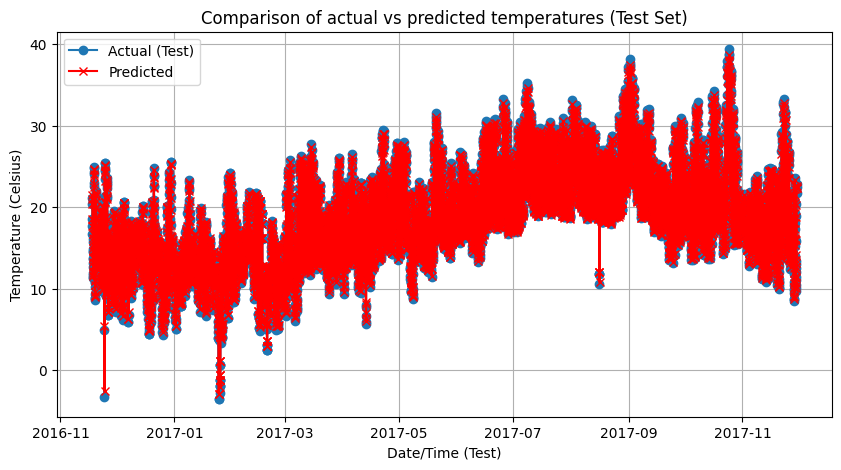

In [ ]:
# Retrieve index of the test set (X_test) and store them in test_index
test_index = X_test.index

# Assign the predicted temperature values (preds) to the 'predC' column in df,
# specifically for the rows indicated by test_index
df.loc[test_index, 'predC'] = preds

# Create a new figure for plotting, sized 10 inches wide x 5 inches high
plt.figure(figsize=(10,5))

# Plot the actual temperatures (tempC) for the test set, using 'date' on the x-axis
# The plot is labeled 'Actual (Test)' and uses circular markers ('o')
plt.plot(df.loc[test_index, 'date'], df.loc[test_index, 'tempC'],
         label='Actual (Test)',
         marker='o')

# Plot the predicted temperatures on the same figure, also using 'date' on the x-axis
# The plot is labeled 'Predicted', uses 'x' markers, and is colored red.
plt.plot(df.loc[test_index, 'date'], df.loc[test_index, 'predC'],
         label='Predicted',
         marker='x',
         color='red')

plt.title("Comparison of actual vs predicted temperatures (Test Set)")
plt.xlabel("Date/Time (Test)")
plt.ylabel("Temperature (Celsius)")
plt.legend()
plt.grid(True)
plt.show()


12) **Generate different models with different ML algorithms**


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Linear": LinearRegression(),
    "Tree": DecisionTreeRegressor(),
    "Forest": RandomForestRegressor(),
    "KNN": KNeighborsRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"{name}: MAE={mae:.2f}, R2={r2:.2f}")

Linear: MAE=0.85, R2=0.96
Tree: MAE=0.95, R2=0.95
Forest: MAE=0.93, R2=0.95
KNN: MAE=0.98, R2=0.95


#TODO: **Change the model (Linear Regression)**
Predict based on previous hour (-1h) and previous day (-24h)

Hint: Add one column to the train&test DataFrames

